# scuva walkthrough

This notebook shows a minimal `scanpy` workflow together with the current `scuva` plotting helpers.

It is meant to demonstrate the library as it exists today:

- qc filtering and plotting
- categorical and continuous UMAP plotting
- categorical color overrides
- split UMAP panels
- count and proportion summaries

Assumptions and standards used throughout:

- UMAP coordinates are stored in `adata.obsm["X_umap"]`
- categorical plots use `adata.obs` columns with categorical dtype
- display renaming can be provided through `adata.uns["rename_dict"]`

In [1]:
import scanpy as sc
import scuva as scv

SEED = 7

In [2]:
adata = sc.read_10x_mtx("../test/data/pbmc3k/hg19")

/Users/nirreiter/code/scuva/src/scuva/graphing/qc_filtering.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(metric_names, fontsize=14)


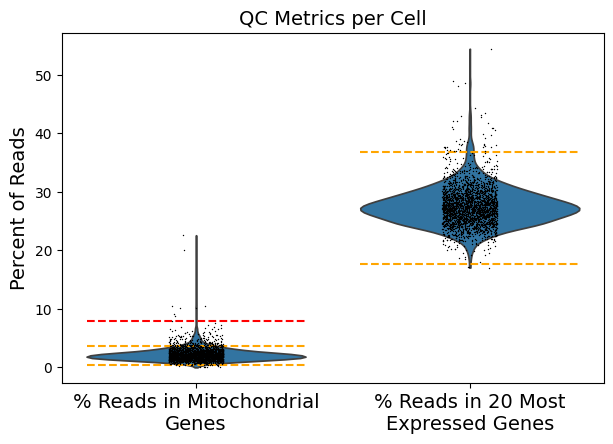

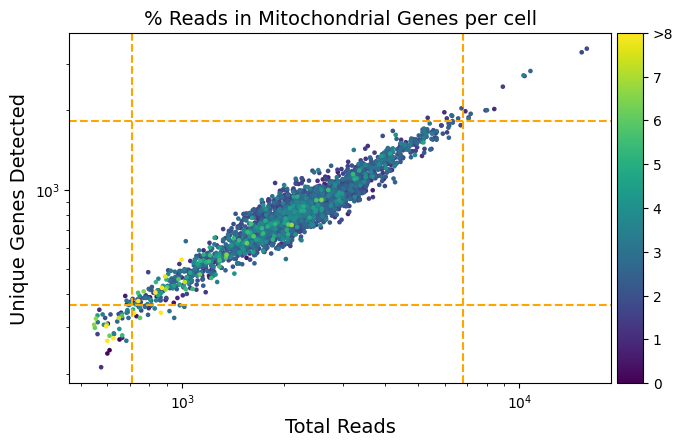

In [3]:
# For a quick example, doublet and ambient RNA removal is not performed. In a real analysis on droplet-based data, they should always be performed.
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, log1p=True, percent_top=[20])
# Using MADs for outliers was suggested by Germain et al. https://doi.org/10.1186/s13059-020-02136-7. These lenient thresholds are chosen from the paper.
is_outlier = (
    scv.is_outlier(adata, "log1p_total_counts", 5)
    | scv.is_outlier(adata, "log1p_n_genes_by_counts", 5)
    | scv.is_outlier(adata, "pct_counts_in_top_20_genes", 5)
    | scv.is_outlier(adata, "pct_counts_mt", 3) | (adata.obs["pct_counts_mt"] > 8)
)
adata.obs["is_outlier"] = is_outlier

ax = scv.qc_metrics_violinplot(adata, ["pct_counts_mt", "pct_counts_in_top_20_genes"])
ax.plot((-0.4, 0.4), (8, 8), color="red", ls="--")

ax = scv.qc_metrics_scatterplot(adata, "pct_counts_mt", 8)

In [4]:
outliers = adata.obs['is_outlier']
print(f"Outliers removed: {(outliers.sum())}")
adata = adata[~outliers, :]
display(adata)

print("\nMin cells filtering for genes: ", end="")
starting_genes = adata.n_vars
sc.pp.filter_genes(adata, min_cells=3) # remove genes found in less than 5 cells
print(f"removed {starting_genes - adata.n_vars} genes")
print(adata)

Outliers removed: 281


View of AnnData object with n_obs × n_vars = 2419 × 32738
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'is_outlier'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'outlier_mad_thresholds'


Min cells filtering for genes: removed 19270 genes
AnnData object with n_obs × n_vars = 2419 × 13468
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'is_outlier'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'outlier_mad_thresholds'


/Users/nirreiter/code/scuva/test/venv/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:293: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


In [5]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=10_000)
sc.pp.log1p(adata)

/Users/nirreiter/code/scuva/test/venv/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


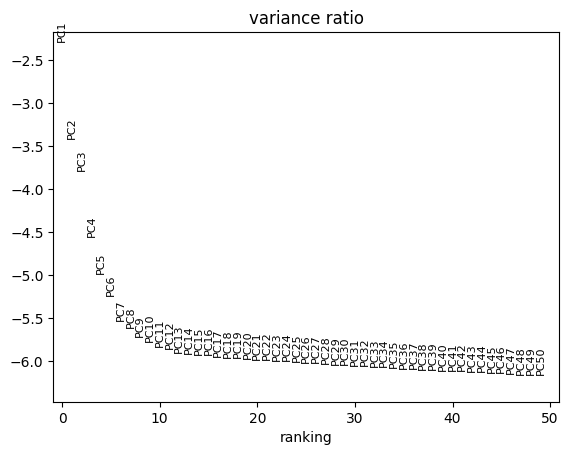

In [6]:
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=2000, layer="counts")
sc.tl.pca(adata, svd_solver="arpack", random_state=SEED, use_highly_variable=True)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

/Users/nirreiter/code/scuva/test/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


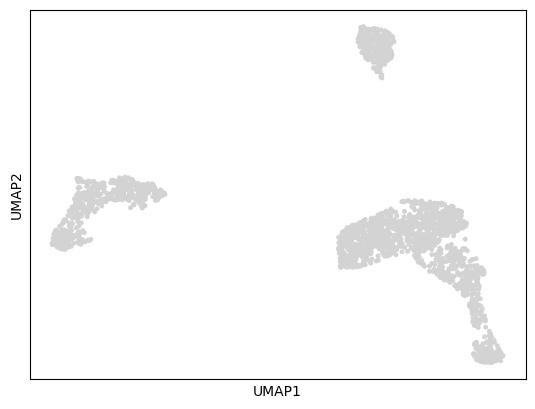

In [7]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=8, use_rep="X_pca",
                method='umap', metric='euclidean', random_state=SEED)
sc.tl.umap(adata, min_dist=0.2, spread=1.0, random_state=SEED)
sc.pl.umap(adata)

## UMAP plotting

After computing a UMAP embedding and a clustering, `scurvy.umap` can draw either a side legend or labels directly on the embedding.

10


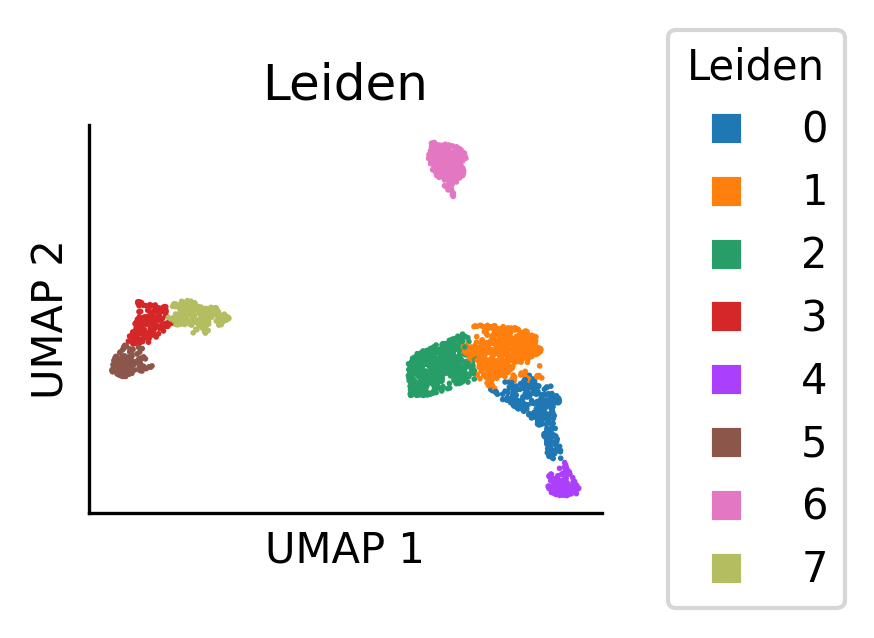

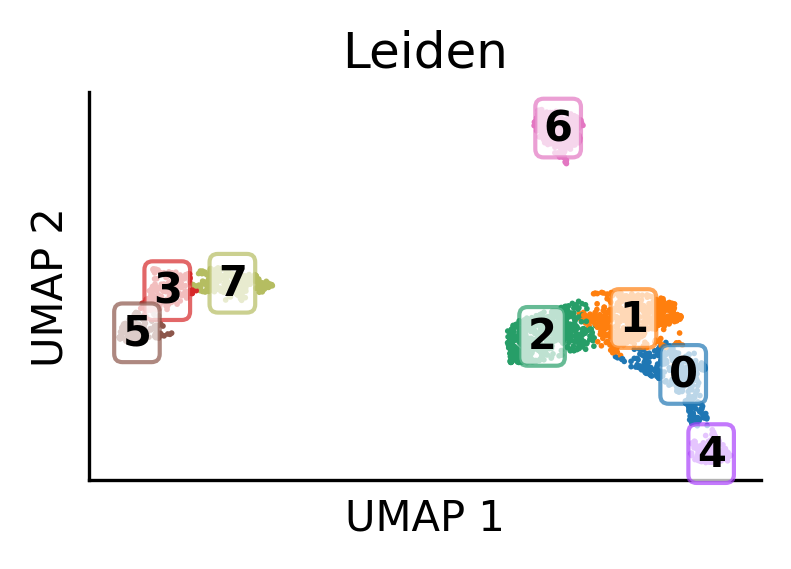

In [11]:
sc.tl.leiden(adata, resolution=0.5, flavor="igraph", n_iterations=2)
scv.umap(adata, "leiden", legend_loc="outside right", figsize=(3, 2));
scv.umap(adata, "leiden", legend_loc="on data", figsize=(3, 2));

### Custom categorical colors

`set_categorical_colors` writes Scanpy-style colors into `adata.uns[f"{feature}_colors"]`, which `scurvy` then reuses across plots.

10


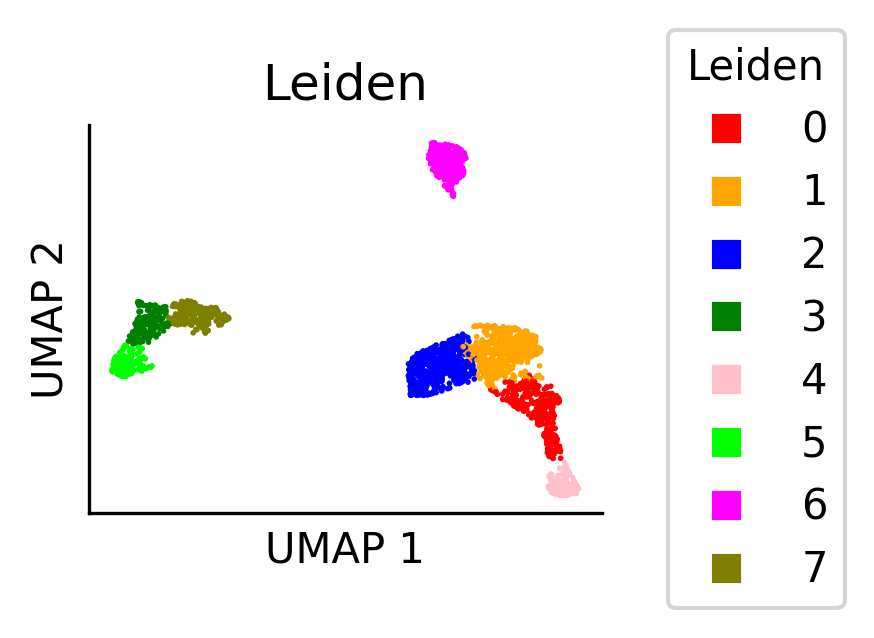

In [12]:
scv.set_categorical_colors(adata, "leiden", {
    "0": "red",
    "1": "orange",
    "2": "blue",
    "3": "green",
    "4": "pink",
    "5": "lime",
    "6": "magenta",
    "7": "olive",
})
scv.umap(adata, "leiden", legend_loc="outside right", figsize=(3, 2));

## Split UMAPs and composition plots

This section creates a simple synthetic sample label (the dataset does not contain multiple samples), then compares cluster structure between samples with split embeddings and bar charts.

In [13]:
import numpy as np
adata.obs["sample"] = np.concatenate([
    np.zeros(len(adata.obs) // 2, int),
    np.ones(len(adata.obs) - len(adata.obs) // 2, int),
])
adata.obs["sample"] = adata.obs["sample"].map({0: "sample_0", 1: "sample_1"}).astype("category")
adata.obs["sample"]

AAACATACAACCAC-1    sample_0
AAACATTGATCAGC-1    sample_0
AAACCGTGCTTCCG-1    sample_0
AAACCGTGTATGCG-1    sample_0
AAACGCACTGGTAC-1    sample_0
                      ...   
TTTCGAACTCTCAT-1    sample_1
TTTCTACTGAGGCA-1    sample_1
TTTCTACTTCCTCG-1    sample_1
TTTGCATGAGAGGC-1    sample_1
TTTGCATGCCTCAC-1    sample_1
Name: sample, Length: 2419, dtype: category
Categories (2, object): ['sample_0', 'sample_1']

10


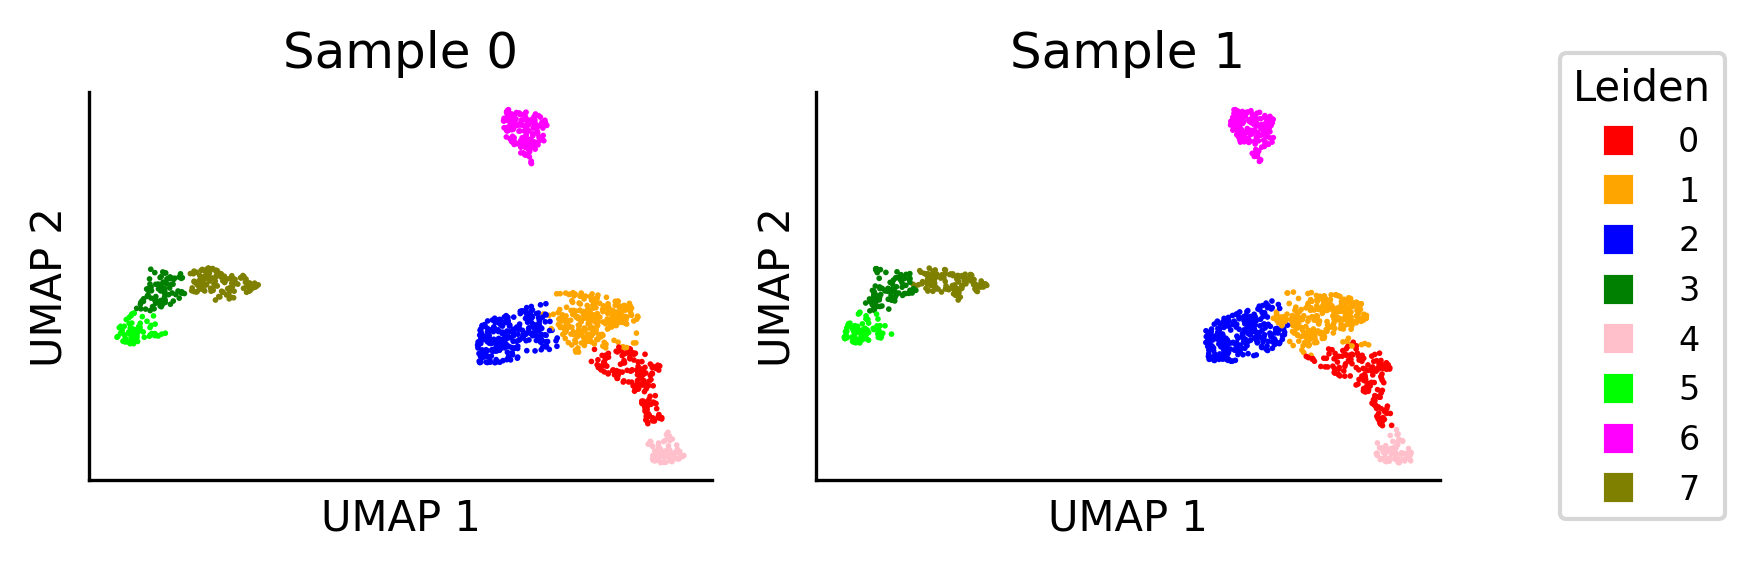

In [15]:
scv.umap_split(adata, "leiden", "sample", legend_orientation="vertical", figsize=(6, 2));

### Counts and proportions

`graph_counts` works directly with the current defaults.

`graph_proportions` currently needs an explicit `percentages_color` in this example because the package default color value is not accepted by Matplotlib.

10


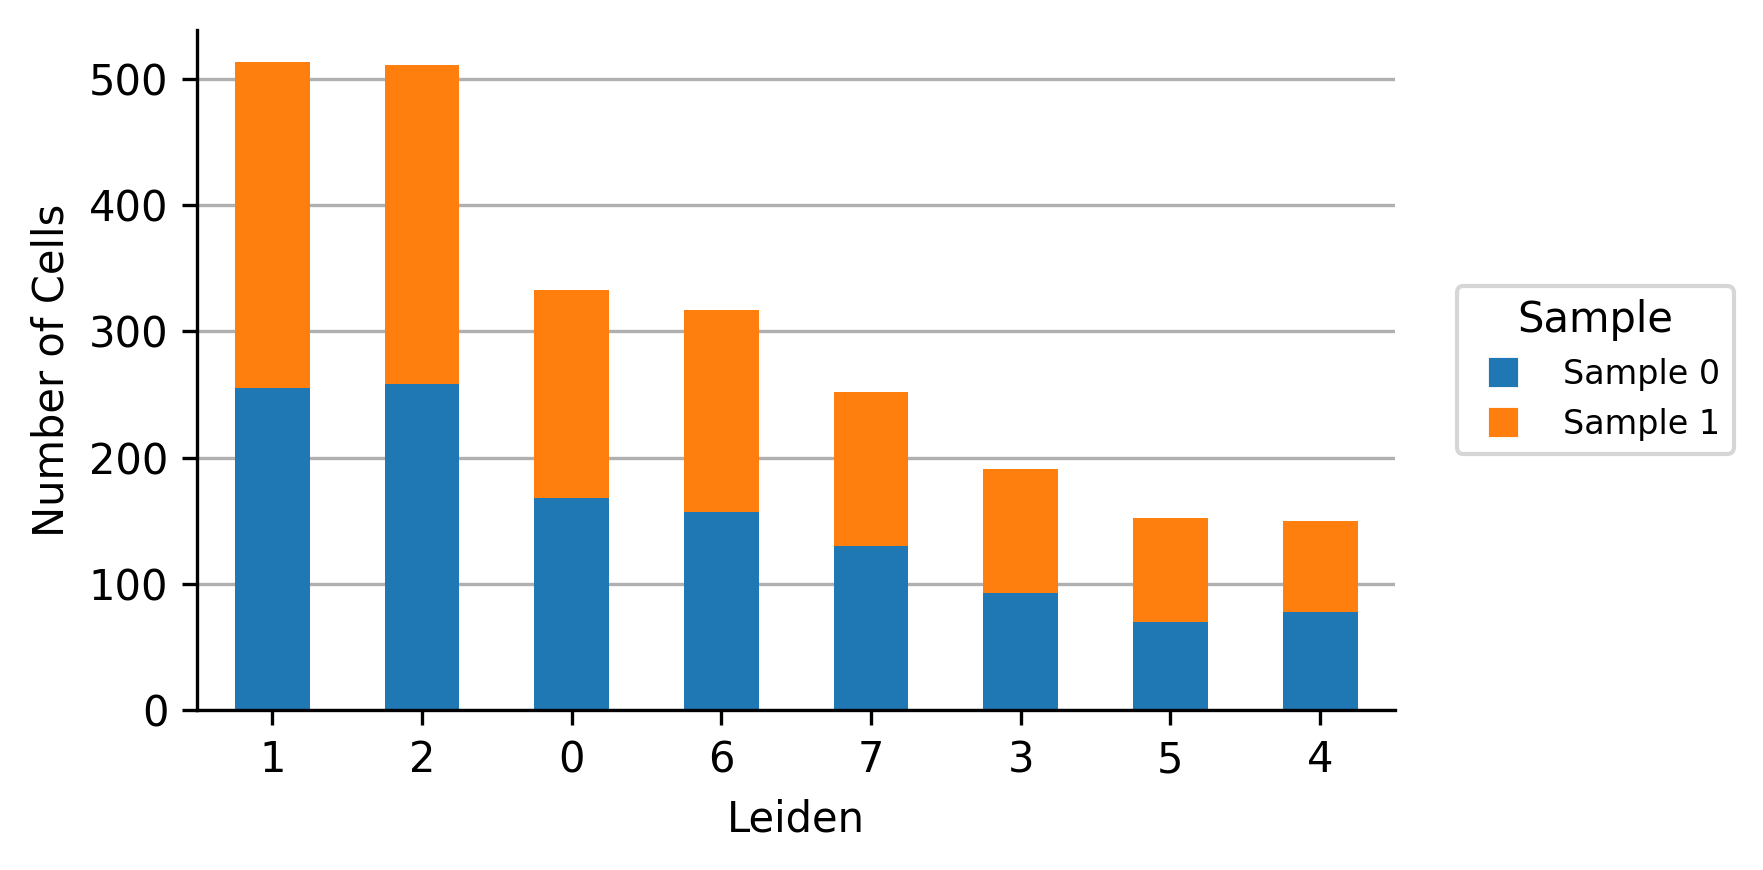

In [16]:
adata.obs["leiden_test"] = adata.obs["leiden"].map(lambda x: f"leiden_{x}")
scv.graph_counts(adata, "sample", "leiden", x_tick_rotation=0, stack=True);

10


/Users/nirreiter/code/scuva/src/scuva/graphing/composition.py:192: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bottom[i] + height/2,


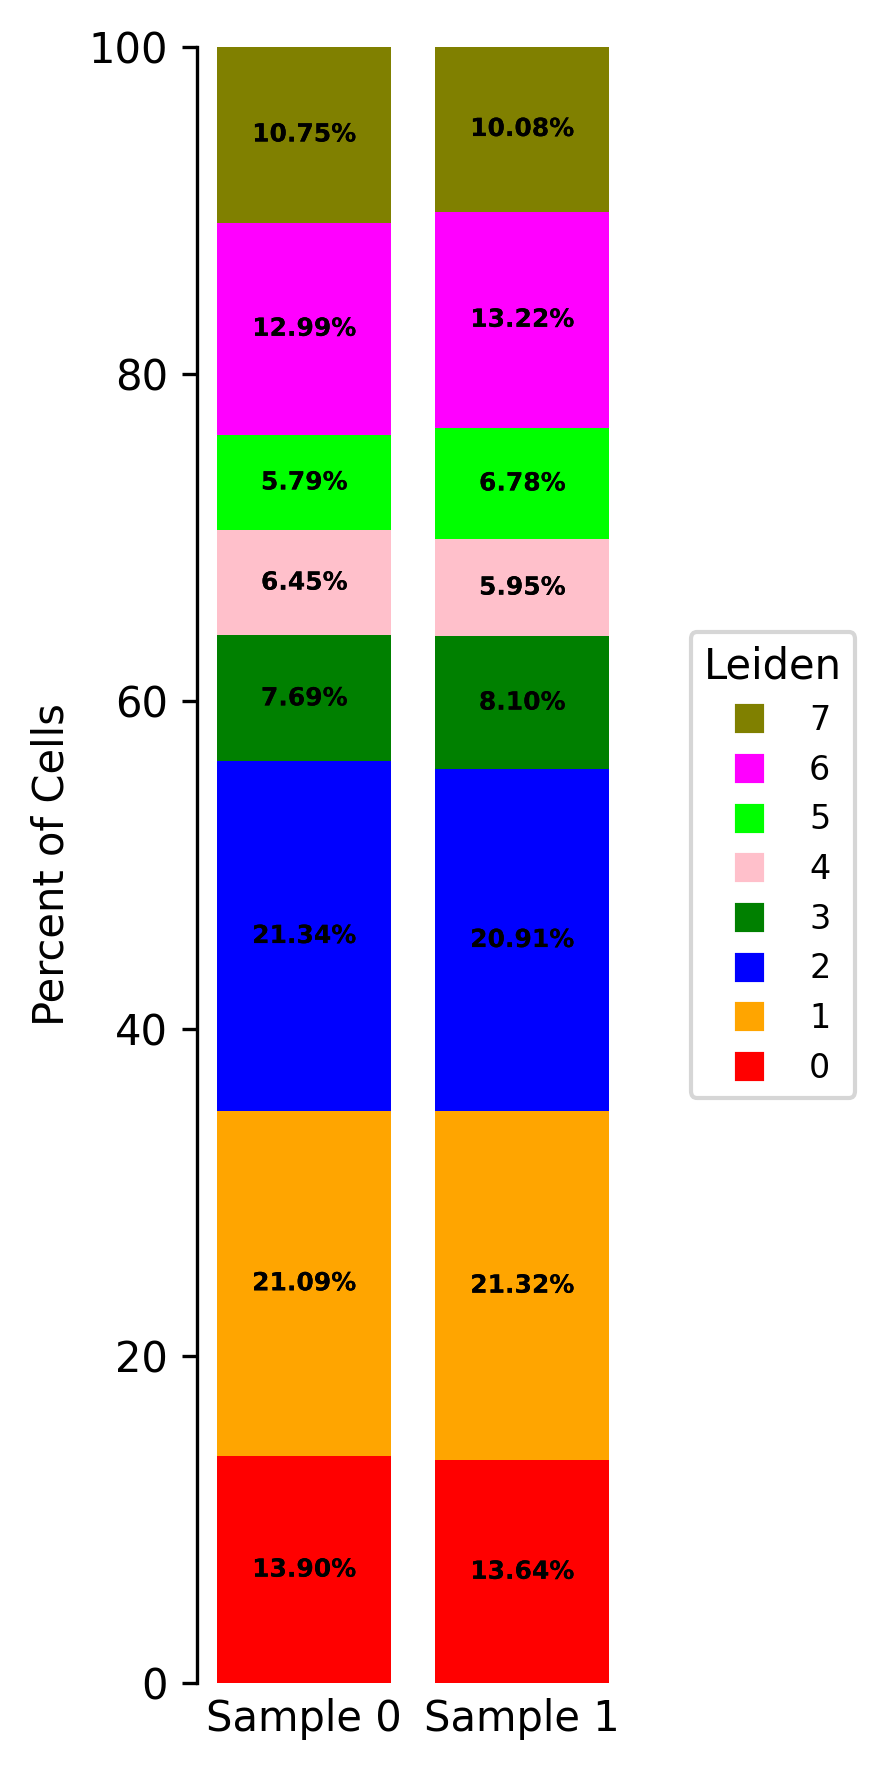

In [17]:
scv.graph_proportions(
    adata,
    "sample",
    "leiden",
    figsize=(3, 6),
    percentages_fontsize=6,
    percentages_outline_width=0
);